# **Exploratory Data Analysis (EDA)** 🌍

Exploratory Data Analysis aime to:


*   Ensure Data **Quality**, **Validation**, and **Completeness**
*   Understand the structure, patterns, and relationships within a dataset



⚠️***Very Important Notice:***
- There are no fixed rules for EDA (Exploratory Data Analysis) or Data Cleaning.

- The methods you choose depend on your **understanding of the data** and the **goal** of your analysis.

- This notebook is just an introduction with *common use cases* and practical
examples for beginners.

Use it as a **guide**, but always think critically about what makes sense for your dataset!

In [114]:
#pip install opendatasets


In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [116]:
#import opendatasets as od
#df=od.download("https://www.kaggle.com/datasets/prkukunoor/TitanicDataset?select=titanic_data.csv")


In [117]:
df=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [118]:
df=df.drop(["Embarked"], axis=1)

In [119]:
df=df.drop(columns=['Name','PassengerId'])
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN
3,1,1,female,35.0,1,0,113803,53.1000,C123
4,0,3,male,35.0,0,0,373450,8.0500,NaN
5,0,3,male,NaN,0,0,330877,8.4583,NaN
6,0,1,male,54.0,0,0,17463,51.8625,E46
7,0,3,male,2.0,3,1,349909,21.0750,NaN
8,1,3,female,27.0,0,2,347742,11.1333,NaN
9,1,2,female,14.0,1,0,237736,30.0708,NaN


In [120]:
df.duplicated().sum()

np.int64(15)

In [121]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin'],
      dtype='str')

In [122]:
df['Fare'] = df['Fare'].astype('int64')

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    str    
 7   Fare      891 non-null    int64  
 8   Cabin     204 non-null    str    
dtypes: float64(1), int64(5), str(3)
memory usage: 73.6 KB


In [124]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,31.785634
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.703730
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.000000


In [125]:
df['Sex'].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [126]:
df.shape

(891, 9)

In [127]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
dtype: int64

In [128]:
#df=df.drop["Embarked", axis=1]

**Use Case 1: Chack The Datatypes**
- Goal-> Make sure every column has the correct data type — because wrong types can cause errors or incorrect calculations later.

In [129]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': ['25', 'None', '30'],
    'Salary': ['$4000', '$3500', '$5000'],
    'Phone': ['+1-202-555-0182', '202-555-0176', '202-555-0198']
}

df = pd.DataFrame(data)
df.head()


,Name,Age,Salary,Phone
0,Alice,25,$4000,+1-202-555-0182
1,Bob,None,$3500,202-555-0176
2,Charlie,30,$5000,202-555-0198


In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    3 non-null      str  
 1   Age     3 non-null      str  
 2   Salary  3 non-null      str  
 3   Phone   3 non-null      str  
dtypes: str(4)
memory usage: 305.0 bytes


To change the datatype, we use **astype()** or **pd.to_numeric()** but in some cases we have only to use pd.to_numeric() becasue of the non-null and none-numerical values such as the word "None"

In [131]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [132]:
df.head()

,Name,Age,Salary,Phone
0,Alice,25.0,$4000,+1-202-555-0182
1,Bob,NaN,$3500,202-555-0176
2,Charlie,30.0,$5000,202-555-0198


In [133]:
df['Salary'] = df['Salary'].str.strip('$')
df['Salary'] = df['Salary'].astype('float')

In [134]:
df['Phone'] = df['Phone'].str.strip('+1')
df['Phone'] = df['Phone'].str.replace('-','')
df['Phone'] = df['Phone'].str.replace(' ','')
# df['Phone'] = df['Phone'].str.replace(r'\D', '', regex=True)
df['Phone'] = df['Phone'].astype('int')

In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    3 non-null      str    
 1   Age     2 non-null      float64
 2   Salary  3 non-null      float64
 3   Phone   3 non-null      int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 243.0 bytes


In [136]:
df.head()

,Name,Age,Salary,Phone
0,Alice,25.0,4000.0,2025550182
1,Bob,NaN,3500.0,2025550176
2,Charlie,30.0,5000.0,2025550198


**Use Case 2: Validate Numerical Ranges**

In [137]:
data = {
    'Name': ['Alice', 'Charlie', 'Dina', 'Ethan'],
    'Rating(stars)': [4.5, 5, 6, 3],
    'Age': [25, 40, -20, 28]
}

df = pd.DataFrame(data)
df.head()

,Name,Rating(stars),Age
0,Alice,4.5,25
1,Charlie,5.0,40
2,Dina,6.0,-20
3,Ethan,3.0,28


In [138]:
df.describe()

,Rating(stars),Age
count,4.000,4.000000
mean,4.625,18.250000
std,1.250,26.310644
min,3.000,-20.000000
25%,4.125,13.750000
50%,4.750,26.500000
75%,5.250,31.000000
max,6.000,40.000000


In [139]:
df['Age'] = df['Age'].apply('abs')

In [140]:
df['Rating(stars)']=df['Rating(stars)'].replace(6, 5)

In [141]:
df.head()

,Name,Rating(stars),Age
0,Alice,4.5,25
1,Charlie,5.0,40
2,Dina,5.0,20
3,Ethan,3.0,28


**Use Case 3: Incpect Unique Categories**

In [142]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Dina', 'Ethan', 'Fatma', 'George'],
    'Gender': ['Female', 'Female', 'F', 'Woman', 'Male', 'M', 'Man'],
    'Subscribed': ['Yes', 'no', 'YES', 'No', 'yes', 'No', 'nO'],          # different capitalization
}

df = pd.DataFrame(data)
df.head()

,Name,Gender,Subscribed
0,Alice,Female,Yes
1,Bob,Female,no
2,Charlie,F,YES
3,Dina,Woman,No
4,Ethan,Male,yes


In [143]:
df.describe(include='object')

C:\Users\Hp\AppData\Local\Temp\ipykernel_21852\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Gender,Subscribed
count,7,7,7
unique,7,6,6
top,Alice,Female,No
freq,1,2,2


In [144]:
df['Subscribed'].unique()

<ArrowStringArray>
['Yes', 'no', 'YES', 'No', 'yes', 'nO']
Length: 6, dtype: str

In [145]:
df['Subscribed'] = df['Subscribed'].str.upper()

In [146]:
df['Subscribed'].unique()

<ArrowStringArray>
['YES', 'NO']
Length: 2, dtype: str

In [147]:
df['Gender'].unique()

<ArrowStringArray>
['Female', 'F', 'Woman', 'Male', 'M', 'Man']
Length: 6, dtype: str

In [148]:
genders = {'F': 'Female',
           'Woman': 'Female',
           'M': 'Male',
           'Man': 'Male'}

df['Gender'] = df['Gender'].replace(genders)

In [149]:
df['Gender'].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [150]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Use Case 4: Chack For Missing Values**

In [151]:
data = {
    'Name': ['Alice', 'Bob', np.nan, 'Dina', 'Ethan', 'Fatma'],
    'Age': [25, np.nan, 'None', 30, '', 28],
    'Salary': [4000, 3500, np.nan, 'None', 4200, 3900],
    'Department': ['HR', '', '', np.nan, 'None', 'Finance']
}

df = pd.DataFrame(data)
df.head()

,Name,Age,Salary,Department
0,Alice,25,4000,HR
1,Bob,NaN,3500,
2,NaN,None,NaN,
3,Dina,30,None,NaN
4,Ethan,,4200,None


In [152]:
df.isnull() #or isna

,Name,Age,Salary,Department
0,False,False,False,False
1,False,True,False,False
2,True,False,True,False
3,False,False,False,True
4,False,False,False,False
5,False,False,False,False


In [153]:
df.isnull().sum()

Name          1
Age           1
Salary        1
Department    1
dtype: int64

In [154]:
df['Department'].unique()

<ArrowStringArray>
['HR', '', nan, 'None', 'Finance']
Length: 5, dtype: str

In [155]:
df = df.replace(['None', '', 'NA', 'na', 'null'], np.nan)

In [156]:
df.isnull().sum()

Name          1
Age           3
Salary        2
Department    4
dtype: int64

In [157]:
df.isnull().mean()*100

Name          16.666667
Age           50.000000
Salary        33.333333
Department    66.666667
dtype: float64

In [158]:
df.isna().all(axis=1)

0    False
1    False
2     True
3    False
4    False
5    False
dtype: bool

In [159]:
df.isna().all(axis=1).sum()

np.int64(1)

In [160]:
all_null_rows = df.isnull().all(axis=1)
all_null_rows = df.index[all_null_rows].tolist()
all_null_rows

[2]

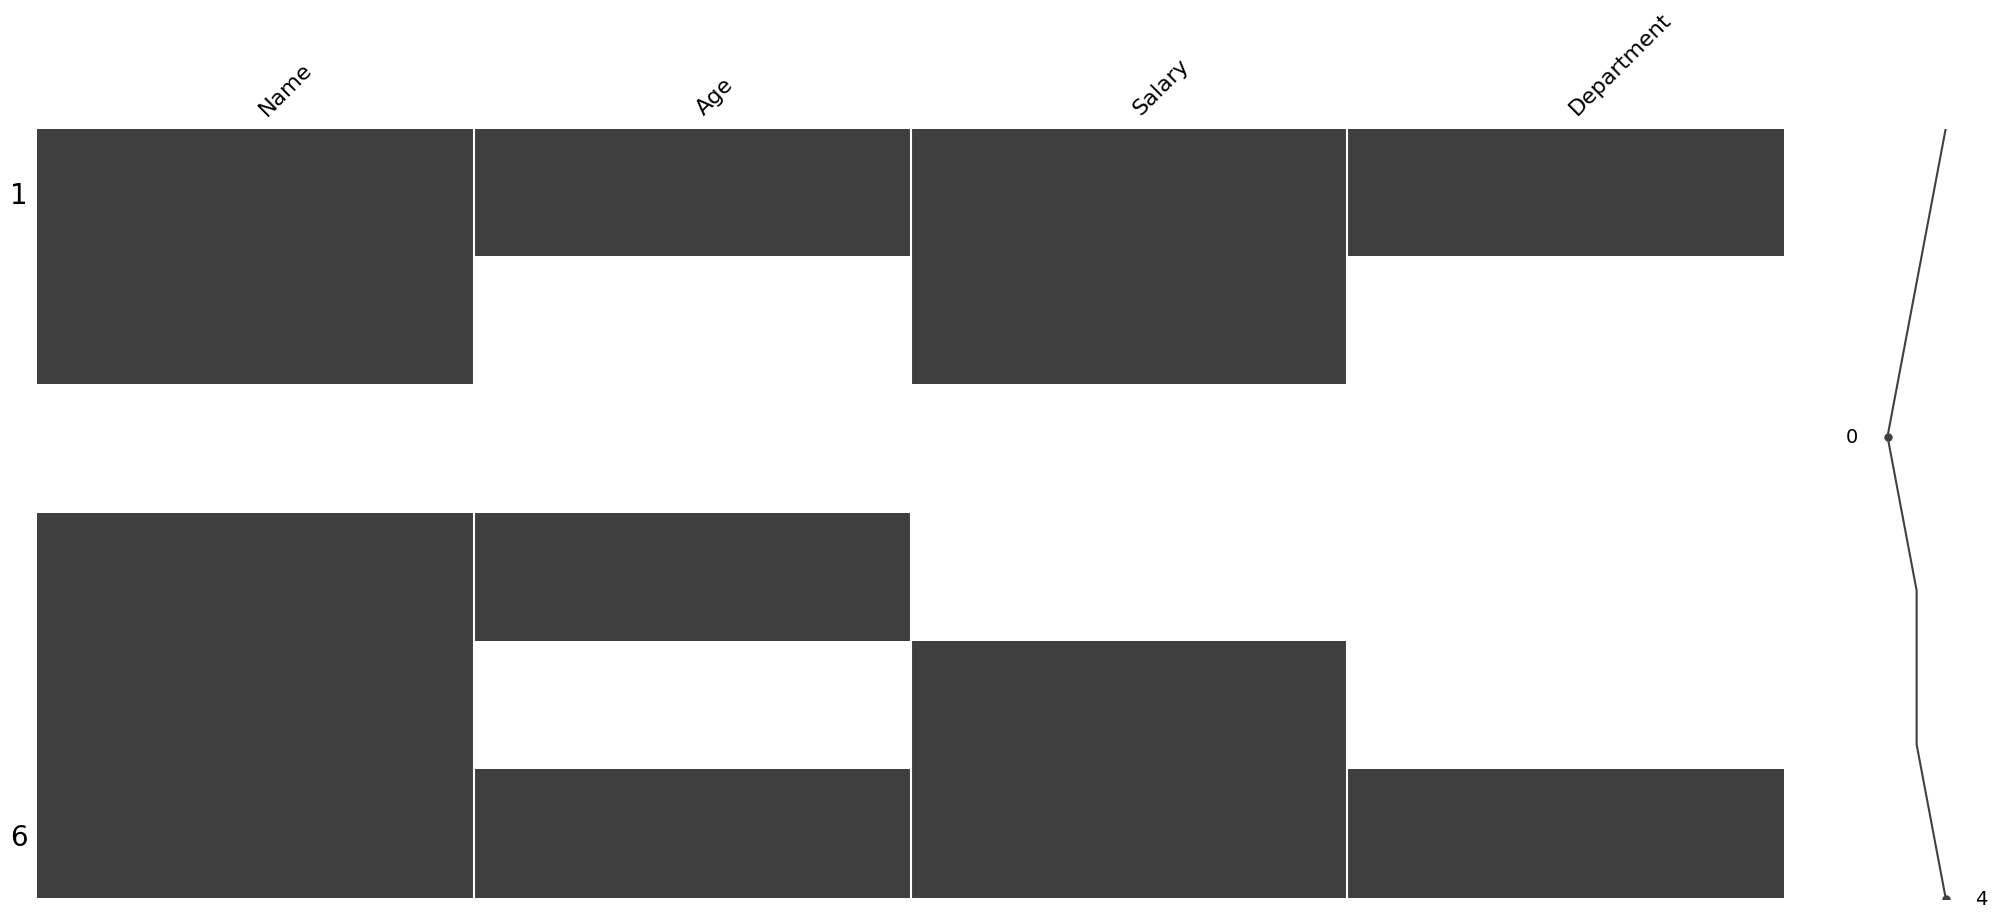

In [162]:
import missingno as msno
msno.matrix(df)
plt.show()

In [163]:
df.dropna()

,Name,Age,Salary,Department
0,Alice,25,4000,HR
5,Fatma,28,3900,Finance


In [164]:
col_mean = df["Age"].mean()
df["Age"].fillna(col_mean, inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_21852\1247888383.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(col_mean, inplace=True)


0           25
1    27.666667
2    27.666667
3           30
4    27.666667
5           28
Name: Age, dtype: object

**Use Case 5: Chack For Duplicats**

In [165]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Alice', 'Dina', 'Bob'],
    'Age': [25, 30, 35, 25, 28, 30],
    'Salary': [4000, 3500, 5000, 4000, 4200, 3500],
    'Department': ['HR', 'IT', 'Finance', 'HR', 'IT', 'IT']
}

df = pd.DataFrame(data)
df

,Name,Age,Salary,Department
0,Alice,25,4000,HR
1,Bob,30,3500,IT
2,Charlie,35,5000,Finance
3,Alice,25,4000,HR
4,Dina,28,4200,IT
5,Bob,30,3500,IT


In [166]:
df.duplicated().sum()

np.int64(2)

In [167]:
df.duplicated(keep=False)

0     True
1     True
2    False
3     True
4    False
5     True
dtype: bool

In [168]:
duplicates = df.duplicated(keep=False)
df[duplicates]

,Name,Age,Salary,Department
0,Alice,25,4000,HR
1,Bob,30,3500,IT
3,Alice,25,4000,HR
5,Bob,30,3500,IT


In [169]:
df.duplicated().sum()

np.int64(2)

In [170]:
df['ID'] = [1, 2, 3, 4, 5, 6]

In [171]:
df.head(6)

,Name,Age,Salary,Department,ID
0,Alice,25,4000,HR,1
1,Bob,30,3500,IT,2
2,Charlie,35,5000,Finance,3
3,Alice,25,4000,HR,4
4,Dina,28,4200,IT,5
5,Bob,30,3500,IT,6


In [172]:
df.duplicated().sum()

np.int64(0)

In [173]:
df.duplicated(subset=['ID','Name'])

0    False
1    False
2    False
3    False
4    False
5    False
dtype: bool

In [174]:
df.duplicated(subset=['Name']).sum()

np.int64(2)

In [175]:
df = df.drop_duplicates()


**Use Case 6: Detecting Outliers**

In [176]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Dina', 'Ethan', 'Fatma', 'George'],
    'Age': [25, 30, 35, 28, 200, 27, 29],
    'Salary': [4000, 3500, 5000, 4200, 3800, 100000, 3900],
    'Rating': [4.5, 5, 5, 4, 3, 5, 3]
}

df = pd.DataFrame(data)
df

,Name,Age,Salary,Rating
0,Alice,25,4000,4.5
1,Bob,30,3500,5.0
2,Charlie,35,5000,5.0
3,Dina,28,4200,4.0
4,Ethan,200,3800,3.0
5,Fatma,27,100000,5.0
6,George,29,3900,3.0


In [177]:
df.describe()

,Age,Salary,Rating
count,7.000000,7.000000,7.000000
mean,53.428571,17771.428571,4.214286
std,64.706664,36262.410027,0.906327
min,25.000000,3500.000000,3.000000
25%,27.500000,3850.000000,3.500000
50%,29.000000,4000.000000,4.500000
75%,32.500000,4600.000000,5.000000
max,200.000000,100000.000000,5.000000


In [178]:
numeric_cols = ['Age', 'Salary', 'Rating']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Outliers in {col}:")
    print(outliers[[col]])
    print("-"*30)


Outliers in Age:
   Age
4  200
------------------------------
Outliers in Salary:
   Salary
5  100000
------------------------------
Outliers in Rating:
Empty DataFrame
Columns: [Rating]
Index: []
------------------------------


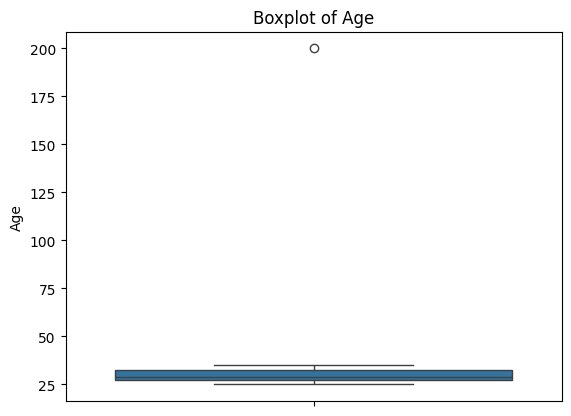

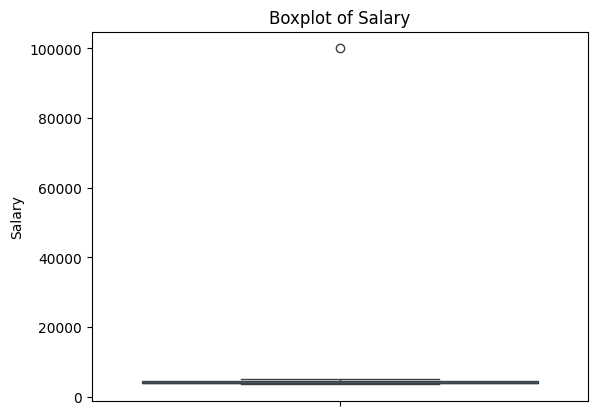

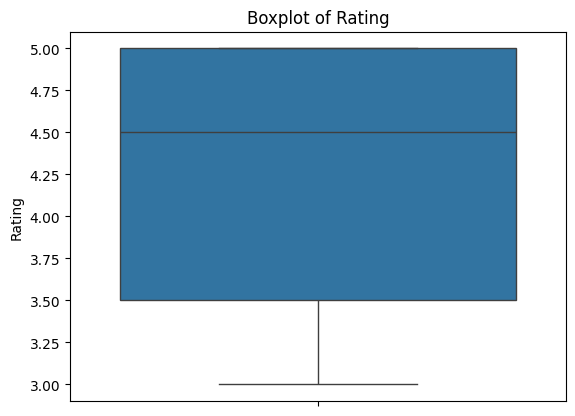

In [179]:
for col in numeric_cols:
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Use Case 7: Explore Distributions**

Understand the frequency, spread, and shape of each variable.


In [180]:

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Dina', 'Ethan', 'Fatma', 'Ahmed', 'Hana', 'Ibrahim', 'Jana'],
    'Age': [25, 30, 35, 28, 32, 27, 29, 31, 40, 26],
    'Salary': [4000, 3500, 5000, 4200, 3800, 3900, 4100, 4300, 4800, 3700],
    'Rating': [4, 5, 4, 3, 5, 4, 3, 5, 4, 3],
    'Department': ['HR', 'IT', 'Finance', 'HR', 'IT', 'Finance', 'IT', 'HR', 'Finance', 'IT']
}

df = pd.DataFrame(data)
df

,Name,Age,Salary,Rating,Department
0,Alice,25,4000,4,HR
1,Bob,30,3500,5,IT
2,Charlie,35,5000,4,Finance
3,Dina,28,4200,3,HR
4,Ethan,32,3800,5,IT
5,Fatma,27,3900,4,Finance
6,Ahmed,29,4100,3,IT
7,Hana,31,4300,5,HR
8,Ibrahim,40,4800,4,Finance
9,Jana,26,3700,3,IT


In [181]:
df.describe()

,Age,Salary,Rating
count,10.000000,10.000000,10.000000
mean,30.300000,4130.000000,4.000000
std,4.522782,471.522357,0.816497
min,25.000000,3500.000000,3.000000
25%,27.250000,3825.000000,3.250000
50%,29.500000,4050.000000,4.000000
75%,31.750000,4275.000000,4.750000
max,40.000000,5000.000000,5.000000


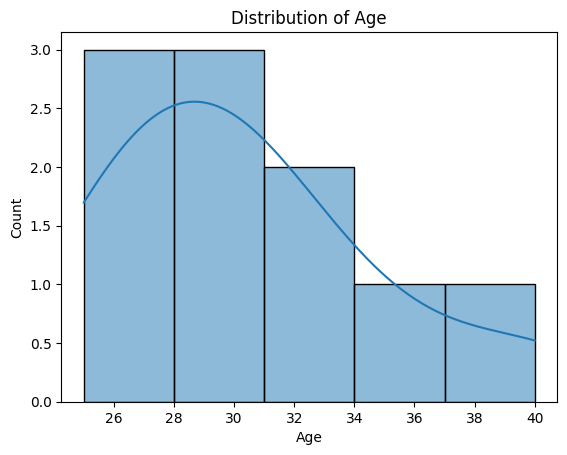

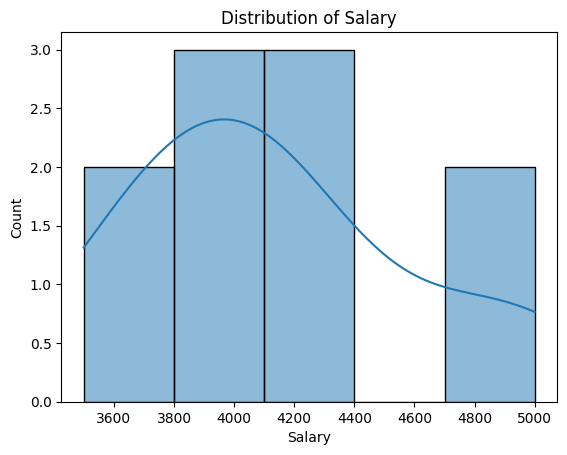

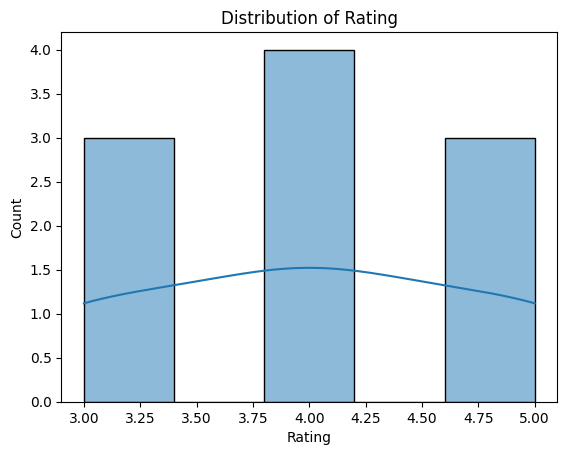

In [182]:
numeric_cols = ['Age', 'Salary', 'Rating']

for col in numeric_cols:
    sns.histplot(df[col], kde=True, bins=5)
    plt.title(f"Distribution of {col}")
    plt.show()


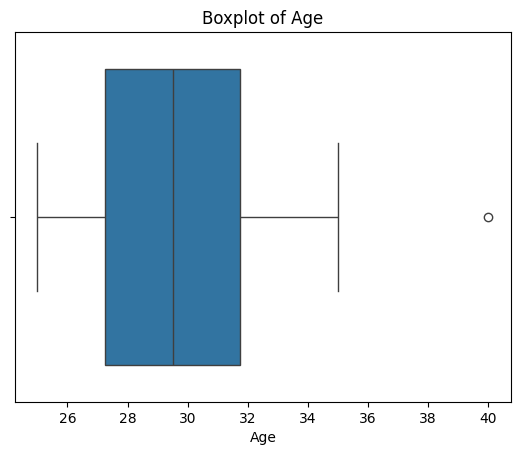

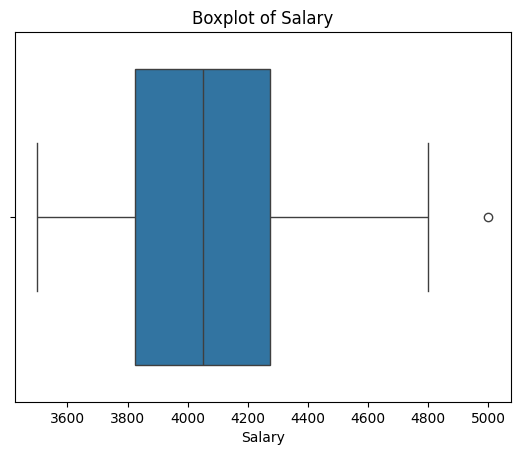

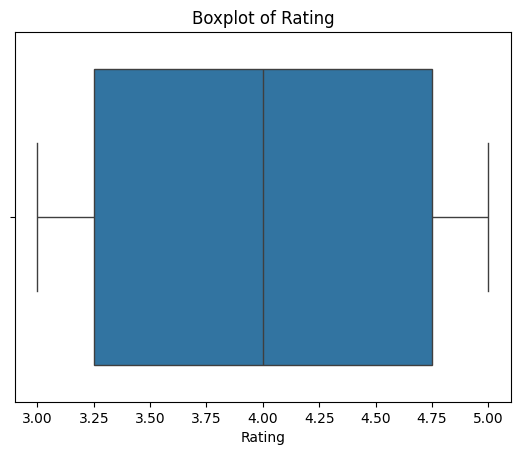

In [183]:
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


**Use Case 8: Explore Relationships**

1- Numeric vs Numeric — Correlation

             Age    Salary    Rating
Age     1.000000  0.703890  0.300883
Salary  0.703890  1.000000 -0.115441
Rating  0.300883 -0.115441  1.000000


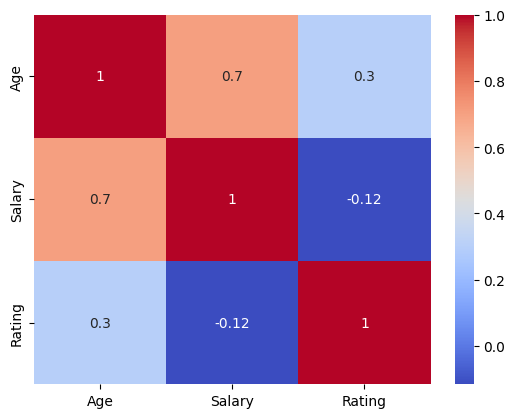

In [184]:
corr = df[numeric_cols].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

2- Numeric vs Categorical — Boxplots

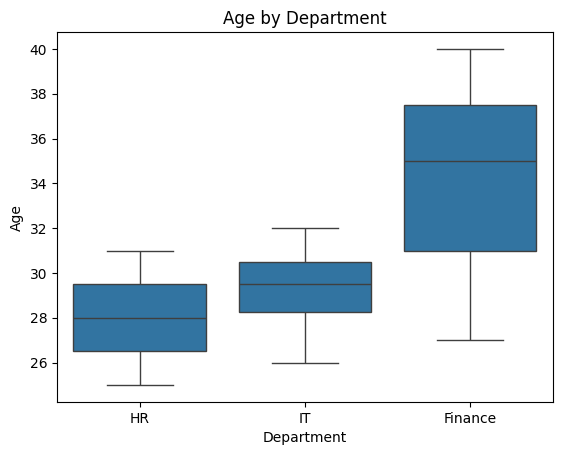

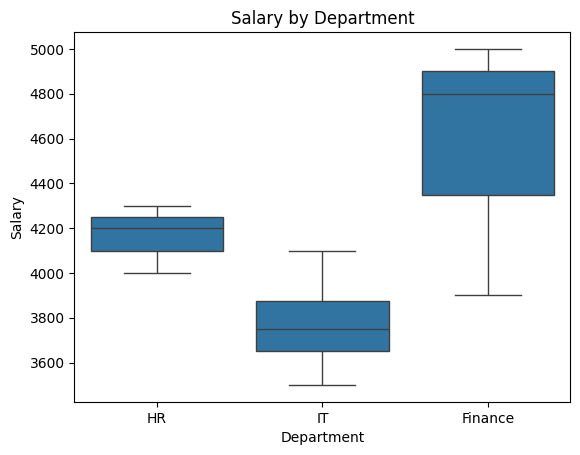

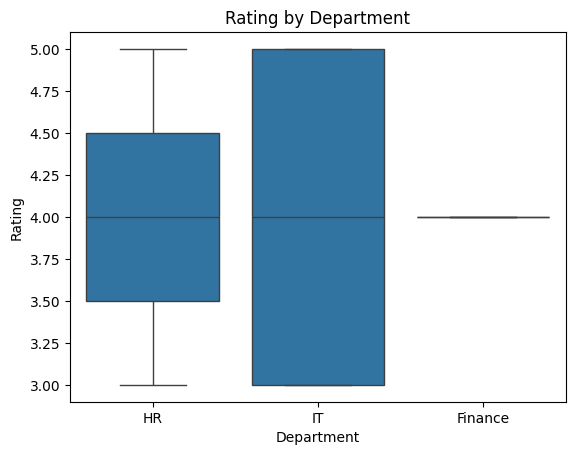

In [185]:
for col in numeric_cols:
    sns.boxplot(x=df['Department'], y=df[col])
    plt.title(f"{col} by Department")
    plt.show()

3- Categorical vs Categorical - Countplot

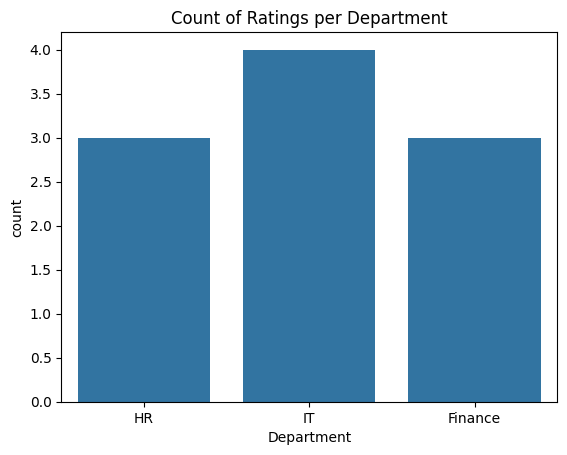

In [186]:
sns.countplot(x='Department', data=df)
plt.title("Count of Ratings per Department")
plt.show()

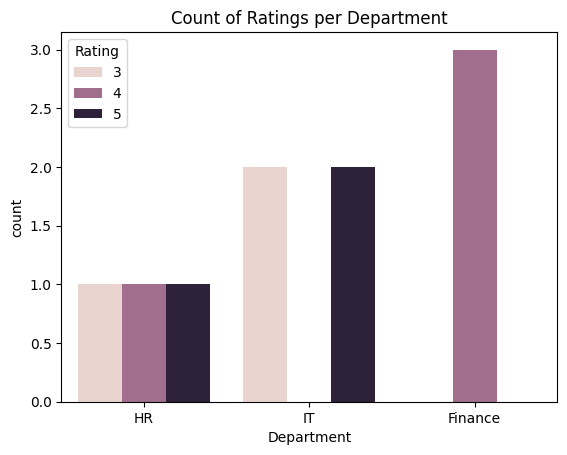

In [187]:
sns.countplot(x='Department', hue='Rating', data=df)
plt.title("Count of Ratings per Department")
plt.show()